Fuente de los datos: https://data.buenosaires.gob.ar/dataset/divorcios
En este mismo repositorio encontraras el archivo con la limpieza que se le hizo a los datos. Los datasets originales usados en data_raw.

contacto: rociobelenrivera2709@gmail.com

instagram: @sanzen.data

tiktok: @sanzen.2026

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("data/dataset_final.csv", sep=',')
df_meses = pd.read_csv("data/dataset_meses.csv", sep=',')
df_anios = pd.read_csv("data/dataset_anios.csv", sep=',')

El dataset final cuenta con 42.720 registros en total. 


fecha_divorcio: fecha en la que se inscribio el divorcio

sexo_1: sexo de una de las personas que conforman el matrimonio

sexo_2: sexo de la otra persona que conforma el matrimonio

fecha_matrimino: fecha en la que ambas personas se casaron

tiempo_transcurrido: tiempo transcurrido desde que se casaron hasta que se divorciaron en días

anios_matrimonio: tiempo transcurrido desde que se casaron hasta que se divorciaron en años

anio_divorcio: componente año de fecha_divorcio. Año del divorcio

anio_matrimonio: componente año de fecha_matrimonio. Año de matrimonio

mes_divorcio: componente mes de fecha_divorcio. Mes del divorcio

tipo_pareja: si es una pareja de diferente sexo, mismo sexo o "no declara"

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42720 entries, 0 to 42719
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha_divorcio       42720 non-null  str    
 1   sexo_1               42636 non-null  str    
 2   sexo_2               42639 non-null  str    
 3   fecha_matrimonio     42719 non-null  str    
 4   tiempo_transcurrido  42719 non-null  str    
 5   anios_matrimonio     42719 non-null  float64
 6   anio_divorcio        42720 non-null  int64  
 7   anio_matrimonio      42719 non-null  float64
 8   mes_divorcio         42720 non-null  int64  
 9   tipo_pareja          42720 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 3.3 MB


Duración promedio de los matrimonios divorciados para cada año desde el 2018 al 2025:

In [19]:
print(df.groupby('anio_divorcio')['anios_matrimonio'].mean())

anio_divorcio
2018    18.988156
2019    19.283704
2020    19.112042
2021    19.059741
2022    20.119966
2023    20.268810
2024    19.430937
2025    19.933015
Name: anios_matrimonio, dtype: float64


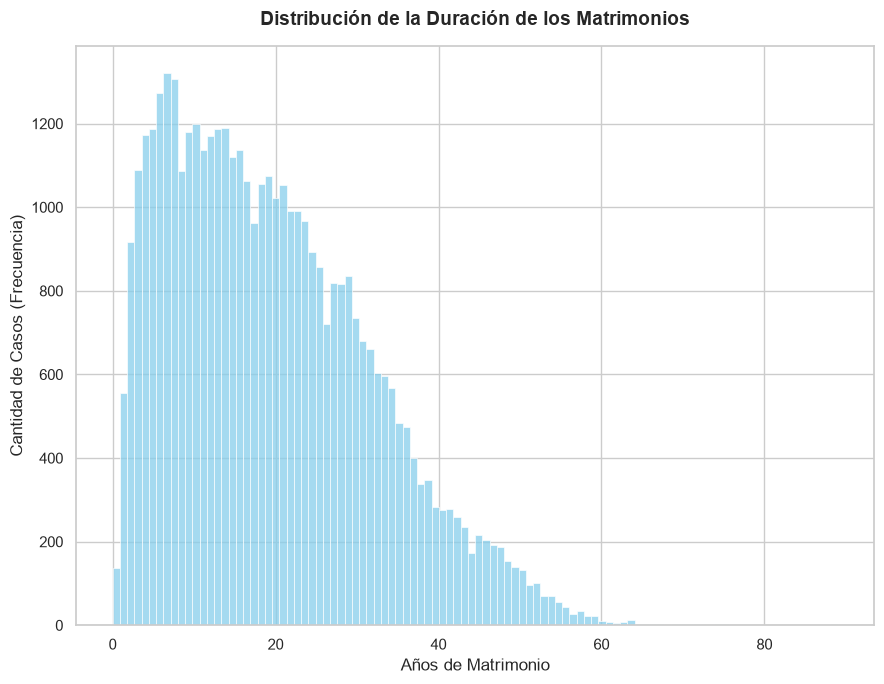

In [20]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 7))

sns.histplot(
    data=df,
    x='anios_matrimonio',       
    color='skyblue',  
    bins=100           
)

plt.title('Distribución de la Duración de los Matrimonios', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Años de Matrimonio', fontsize=12)
plt.ylabel('Cantidad de Casos (Frecuencia)', fontsize=12)

plt.tight_layout()
plt.show()

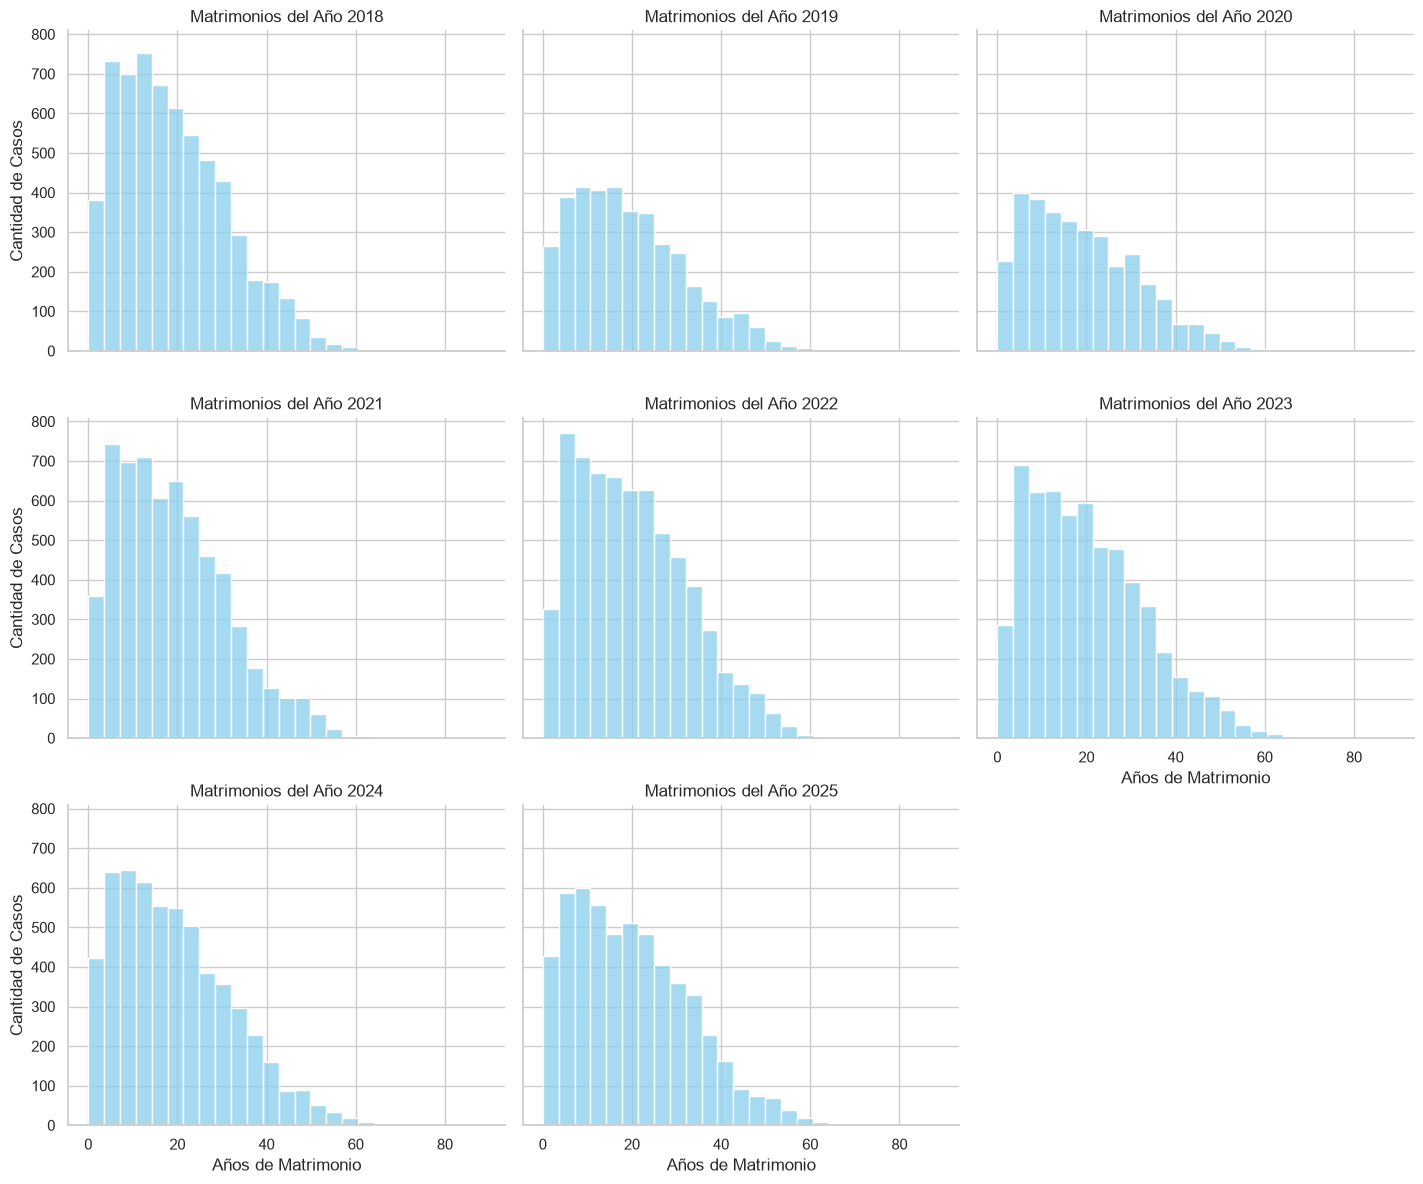

In [18]:
sns.set_theme(style="whitegrid")

g = sns.displot(
    data=df,
    x='anios_matrimonio',
    col='anio_divorcio',
    col_wrap=3,
    kind='hist',          
    color='skyblue', 
    bins=25,         
    height=4,        
    aspect=1.2       
)

g.set_titles("Matrimonios del Año {col_name}")
g.set_axis_labels("Años de Matrimonio", "Cantidad de Casos")

g.tight_layout()
plt.show()

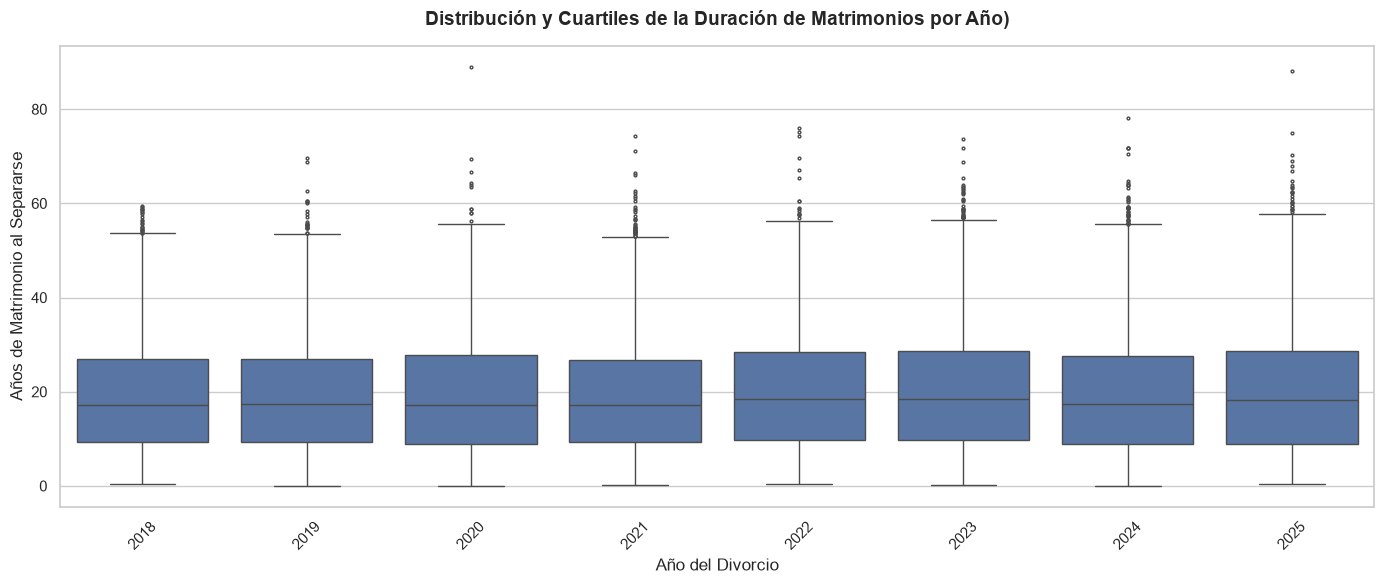

In [31]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6)) 


sns.boxplot(
    data=df,
    x='anio_divorcio',
    y='anios_matrimonio',  
    fliersize=2          
)

plt.title('Distribución y Cuartiles de la Duración de Matrimonios por Año)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Año del Divorcio', fontsize=12)
plt.ylabel('Años de Matrimonio al Separarse', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
df['anios_matrimonio'].mean()

np.float64(19.55959643250076)

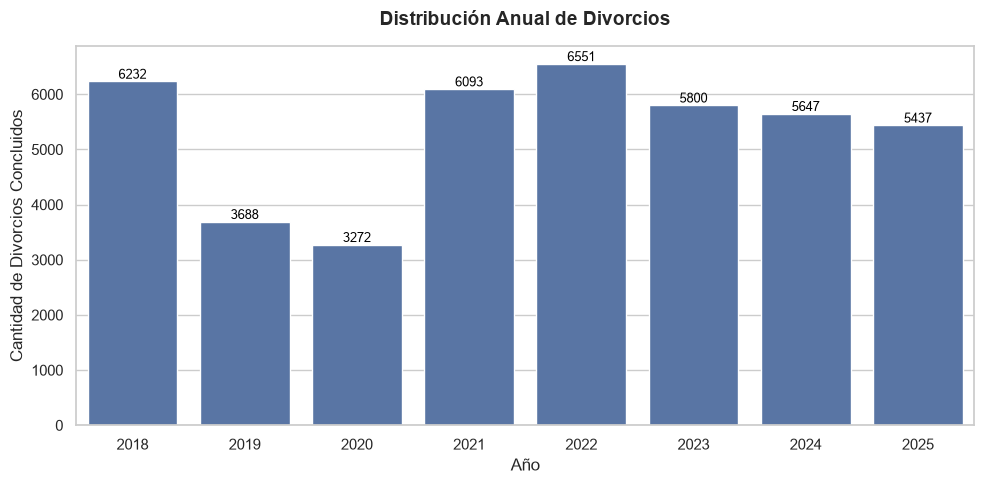

In [22]:

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.barplot(data=df_anios, x='anio_divorcio', y='total_divorcios')

plt.title('Distribución Anual de Divorcios', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Divorcios Concluidos', fontsize=12)

for index, row in df_anios.iterrows():
    plt.text(index, row['total_divorcios'] + 50, str(row['total_divorcios']), color='black', ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
df_meses

,mes_divorcio,total_divorcios
0,1,1383
1,2,2924
2,3,4261
3,4,3751
4,5,3918
5,6,3520
6,7,3062
7,8,3896
8,9,3810
9,10,4023


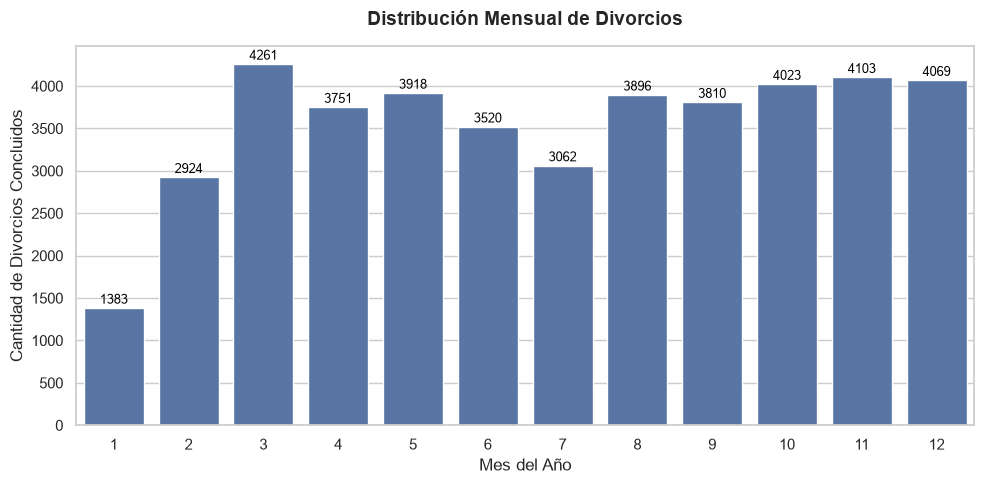

In [24]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.barplot(data=df_meses, x='mes_divorcio', y='total_divorcios')

plt.title('Distribución Mensual de Divorcios', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Cantidad de Divorcios Concluidos', fontsize=12)

for index, row in df_meses.iterrows():
    plt.text(index, row['total_divorcios'] + 50, str(row['total_divorcios']), color='black', ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
df_tipos_parejas= pd.read_csv('data/dataset_tipos_pareja.csv')

In [26]:
df_tipos_parejas

,tipo_pareja,total_divorcios
0,desconocido,6693
1,dif sexo,35895
2,mismo sexo,132


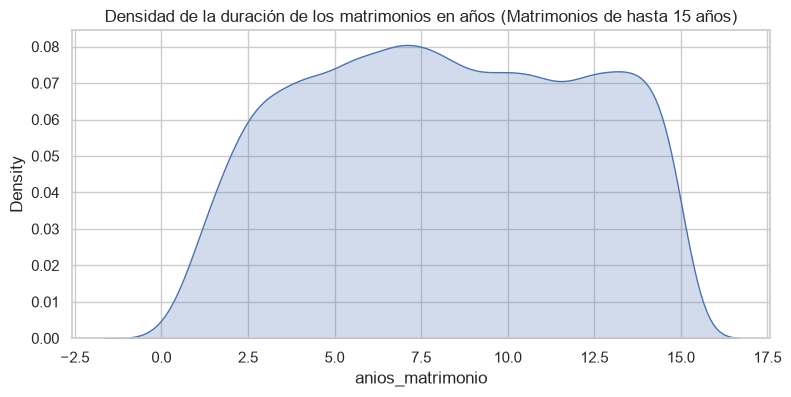

In [34]:
plt.figure(figsize=(9, 4))
sns.kdeplot(data=df[df['anios_matrimonio'] <= 15], x='anios_matrimonio', fill=True, common_norm=False)
plt.title('Densidad de la duración de los matrimonios en años (Matrimonios de hasta 15 años)')
plt.show()

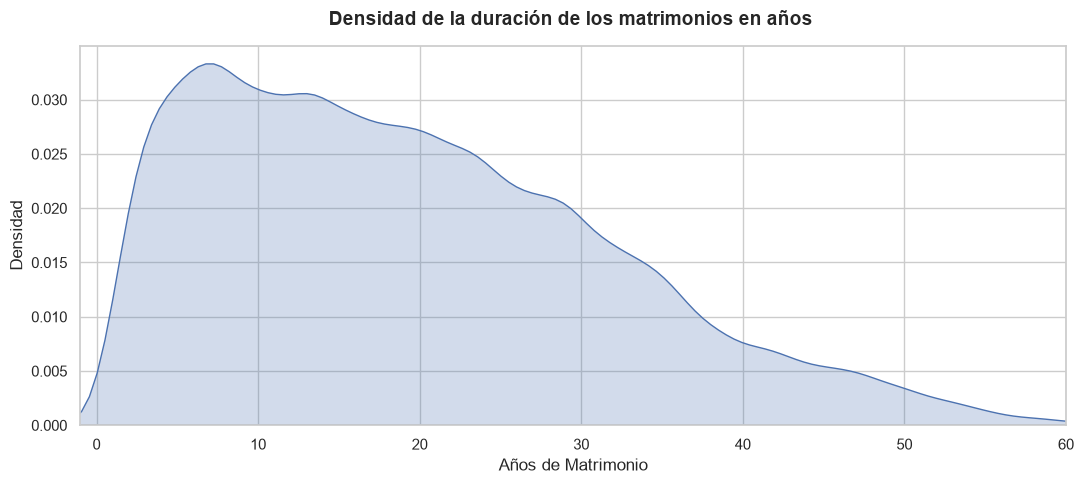

In [35]:
plt.figure(figsize=(11, 5))

sns.kdeplot(
    data=df,                       
    x='anios_matrimonio', 
    fill=True, 
    common_norm=False, 
    bw_adjust=0.75                 
)

plt.xlim(-1, 60)

plt.title('Densidad de la duración de los matrimonios en años ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Años de Matrimonio', fontsize=12)
plt.ylabel('Densidad', fontsize=12)

plt.tight_layout()
plt.show()